# Polarimetric wideband templates


In [ ]:
import sys
sys.path.insert(0, '..') 

import numpy as np
import matplotlib.pyplot as plt
import os
import importlib

#PULSEPORTRAITURE
import pplib_pol as ppl
import ppspline_pol as pps  

#PSRCHIVE
import psrchive as pr   

In [ ]:
importlib.reload(ppl)
importlib.reload(pps)

## Set up your working directories and files 

In [12]:
psr       = 'J0125-2327'     

datadir   = f'data'
resultdir = f'results/{psr}' 
dummy_template  = f"{datadir}/{psr}_dummy.ar" #[optional] this can be an arbitrary archive with selected number of subbands and centre frequencies of the final template

! mkdir -p {resultdir}

## Run the analysis

### Load in a data portrait (I, Q, U, V) and/or (I,L,V)

In [15]:
portrait = f'{datadir}/{psr}.port0'

In [16]:
## Full polarization data portrait
dp = pps.DataPortrait(portrait, state='Stokes')      #state is either 'Intensity' or 'Stokes'


Reading data from data/J0125-2327.port0 on source J0125-2327...
	P [ms]             = 3.675
        DM [cm**-3 pc]     = 9.596234
        RM [rad m**-2]     = 0.000000
        center freq. [MHz] = 2368.0000
        bandwidth [MHz]    = 3328.0
        # bins in prof     = 1024
        # channels         = 832
        # chan (mean)      = 528
        # subints          = 1
        # unzapped subint  = 1
        pol'n state        = Stokes



In [ ]:
#Get polarimetric data if you wish to work with L instead of default Q and U 
#Note, that it may be a bit slow for high resolution data
#dp.polarimetry()

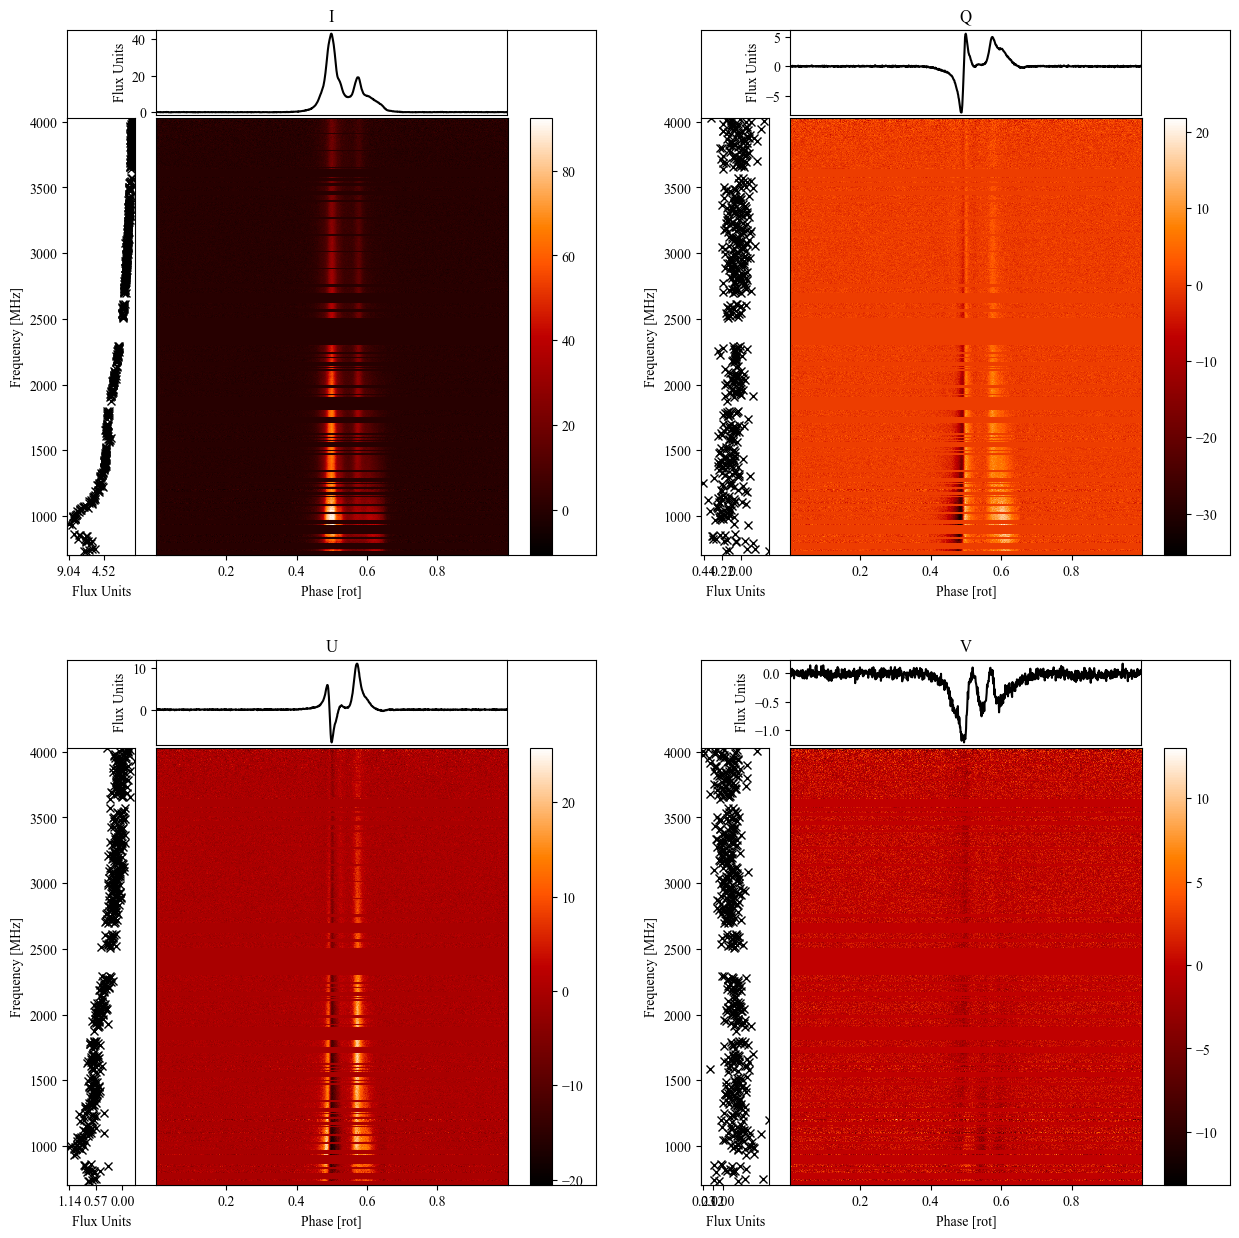

In [17]:
dp.show_data_portrait(state='Stokes',figs=(15,15))   # state is either 'Intensity', 'Stokes' or 'Stokes_L' (requires dp.polarimetry())

## Normalize

In [ ]:
#Normalize
dp.normalize_portrait(method='prof', state='Stokes') #state is either 'Intensity',  'Stokes' or 'Stokes_L'

In [ ]:
dp.show_data_portrait(state='Stokes',figs=(15,15))     # state is either 'Intensity', 'Stokes' or 'Stokes_L'

In [ ]:
#Save the portrait plot
dp.show_data_portrait(state='Stokes', savefig=True, outname=f'{psr}_IQUV', resultdir=f'{resultdir}') # state is either 'Intensity', 'Stokes' or 'Stokes_L'

## Make full Stokes models

In [ ]:
############################################################################
## DEFINE SEPARATELY FOR EACH POL STATE (a list) or USE ONE PARAM FOR ALL (best to start with)
## List of four (I,Q,U,V) state='Stokes'
## List of three (I, L, V) state='Stokes_L' (requires dp.polarimetry() and dp.normalize_portrait(state="Stokes_L")
############################################################################

# use None [default] if analyzing arbitrary data with an unknown number of significant eigenprofiles
max_ncomp = 5
#max_ncomp = [2, 0, 0, 1]    
#max_ncomp = [3, 1, 1]

# the S/N cut off for determining significant eigenprofiles
snr_cutoff = 0
#snr_cutoff = [0,0,0,0] 

# the tolerance around a red. chi2 of 1.0 to help the auto-smoothing of the mean/eigen profiles
# default 0.1
rchi2_tol = 0.1
#rchi2_tol = [0.3,0.3,0.3,0.2]
#rchi2_tol = [0.1,0.2,0.1]

# smoothing "fudge" factor, which will determine the smoothness of the interpolating spline
# default=1
# 0.001 + max_nbreak to change number of break points
# To change the smoothness of the B-spline model, 
# tweak this between 0.0 (interpolating spline that passes through all data points) and a large number (guarantees maximum two breakpoints = maximum smoothness).
sfac = 0.001  #it shouldn't actually be zero, make it very very small instead
#sfac = [0.001, 0.001, 0.001, 0.001]
#sfac = [0.001, 0.001, 0.001]

# the maximum number of spline breakpoints; this may be used instead of sfac. Default None.
max_nbreak = 3
#max_nbreak = [5,3,5,5]      
#max_nbreak = [5,5,4]

# polynomial degree of the B-splines, default 3
k = 3 
#k = [3,4,4,3]
#k = [3,3,4]

############################################################################
## GENERAL PARAMS FOR ALL POL STATES
############################################################################
# smoothing is recommended, but it is not the command-line default
smooth = True                   
#we already normalized the portrait!
norm = None 
#And now the fun begins...
state = 'Stokes'   # Intensity, Stokes, Stokes_L (requires dp.polarimetry())



In [ ]:
## Run PCA

dp.make_spline_model(state=state, max_ncomp=max_ncomp,norm=norm, smooth=smooth, snr_cutoff=snr_cutoff,
                     rchi2_tol=rchi2_tol, k=k, sfac=sfac,max_nbreak=max_nbreak, model_name=None, quiet=False)


## Plot polarimetric models

In [ ]:
dp.show_eigenprofiles(state='Stokes',show_snrs=True)   #state='Stokes', 'Stokes_L', 'Intensity'

In [ ]:
dp.show_spline_curve_projections(state='Stokes')

In [ ]:
dp.show_model_fit(state='Stokes')

#### Save the spline models, archive templates and plots

In [ ]:
#Save models (each spline will be a separate file)
dp.write_model(state='Stokes', resultdir=f'{resultdir}', quiet=False)

#If you want to evaluete template at the same frequencies as in the portrait then run this. 
#It will output fits archive template based on the spline model, called psr_wb.4p.templ0
#If you want to evaluate the template at different frequencies, see cell below
dp.write_model_archive(state='Stokes', resultdir=f'{resultdir}', quiet=False)

#Save plots
dp.show_eigenprofiles(state='Stokes', resultdir=f'{resultdir}', savefig=True)
dp.show_spline_curve_projections(state='Stokes', resultdir=f'{resultdir}', savefig=True)
dp.show_model_fit(state='Stokes', resultdir=f'{resultdir}', savefig=True)

## Save archive templates at any frequencies (as in the dummy template)

In [ ]:
outfile = f'{resultdir}/{psr}_wb.4p.templ'	

dp_templ  = pps.DataPortrait(dummy_template,state='Stokes')

modelfileI = f'{resultdir}/{psr}_I.spl'
modelfileQ = f'{resultdir}/{psr}_Q.spl'
modelfileU = f'{resultdir}/{psr}_U.spl'
modelfileV = f'{resultdir}/{psr}_V.spl'

#Generate template from spline model at given frequencies
_, modelI     = pps.read_spline_model(modelfileI,freqs=dp_templ.freqs[0]) #evaluate model for a given array of frequencies (taken from obs), model[0] - model name, model[1] - profiles
_, modelQ     = pps.read_spline_model(modelfileQ,freqs=dp_templ.freqs[0]) #use dp.freqs[0] instead of dp.freqs to get (nchan, nbin) instead of (nchan,1,nbin)
_, modelU     = pps.read_spline_model(modelfileU,freqs=dp_templ.freqs[0])
_, modelV     = pps.read_spline_model(modelfileV,freqs=dp_templ.freqs[0])

weights   = np.ones((1,len(dp_templ.freqs[0])))	        

shape = dp_templ.arch.get_data().shape					# 
data  = np.zeros(shape)	                                
data  = np.repeat(data, 4, axis=1)                      # set pol=4
shape = data.shape
dp_templ.arch.resize(1,4,shape[2],shape[3])             #np.shape(1, 4, data_chan, data_freq)

#Set some template headers
dp_templ.arch.set_dispersion_measure(0)
dp_templ.arch.set_source(psr)

for isub in range(dp_templ.nsub):
    data[isub,0] = modelI
    data[isub,1] = modelQ
    data[isub,2] = modelU
    data[isub,3] = modelV

pps.unload_new_archive(data,dp_templ.arch,outfile=outfile,DM=0,dmc=0,weights=weights,state="Stokes")